# Generate full paper-style visualization data

In the previous notebook, we ran the full Pig solver and stored the policy as `pig_full_policy.pkl` and the full solution as `pig_full_solution.pkl`. In this notebook, we generate the images 

Run this only after the full Pig solve has completed. The data objects correspond to the paper's main visualizations:

- Figure 3: roll/hold boundary,
- Figure 4: cross-section at opponent score 30,
- Figure 5: reachable states,
- Figure 6: reachable states where rolling is optimal,
- Figure 7: win-probability contours at 3%, 9%, 27%, and 81%.

## 1. Load in files

Note that Figure 7 requires the full value table `full_V`. If only `pig_full_policy.pkl` is available, Figures 3-6 still work and Figure 7 is skipped.

In [1]:
# Import modules
from pathlib import Path
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt

project_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "optimal_pig" / "__init__.py").exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError("Could not find src/optimal_pig from the current working directory.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

data_dir = project_root / "experiments" / "pig_experiment"
figures_dir = data_dir / "Figures"
figures_dir.mkdir(parents=True, exist_ok=True)

import optimal_pig.pig as pig
import optimal_pig.analysis_helpers as ah

print("Imported modules successfully.")
print("pig module:", pig.__file__)
print("analysis_helpers:", ah.__file__)
print("data_dir:", data_dir)


Imported modules successfully.
pig module: c:\Users\Lenovo\Desktop\Game_of_Pig_Assessment_3_main\src\optimal_pig\pig.py
analysis_helpers: c:\Users\Lenovo\Desktop\Game_of_Pig_Assessment_3_main\src\optimal_pig\analysis_helpers.py
data_dir: c:\Users\Lenovo\Desktop\Game_of_Pig_Assessment_3_main\experiments\pig_experiment


In [2]:
# Load in files
import pickle
from pathlib import Path

RUN_FULL_PIG = False
restricted_k = False
full_pig_spec = pig.make_spec(target_score=100)

solution_path = data_dir / "pig_full_solution.pkl"
policy_path = data_dir / "pig_full_policy.pkl"

full_V = None

if solution_path.exists():
    with solution_path.open("rb") as f:
        full_solution = pickle.load(f)

    full_policy = full_solution["policy"]
    full_V = full_solution.get("V")
    restricted_k = bool(full_solution.get("restricted_k", False))
    target_score = int(full_solution.get("target_score", 100))
    full_pig_spec = pig.make_spec(target_score=target_score)
    print(f"Loaded full solution from {solution_path}")

elif policy_path.exists():
    with policy_path.open("rb") as f:
        full_policy = pickle.load(f)

    print(f"Loaded full policy from {policy_path}")
    print("No full value table was found; Figure 7 will be skipped.")

else:
    raise FileNotFoundError(
        f"Run the full Pig solve once, or place pig_full_policy.pkl / "
        f"pig_full_solution.pkl in {data_dir}."
    )

print("Full policy shape:", full_policy.shape)
print("restricted_k:", restricted_k)


Loaded full solution from c:\Users\Lenovo\Desktop\Game_of_Pig_Assessment_3_main\experiments\pig_experiment\pig_full_solution.pkl
Full policy shape: (100, 100, 100)
restricted_k: False


In [ ]:
# Change data format for figures
fig3_data = ah.figure3_boundary_data(
    full_policy,
    include_terminal_boundary=True,
)



full_fig5_data = ah.figure5_reachable_data(
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)

full_fig4_data = ah.figure4_cross_section_data(
    full_policy,
    opponent_score=30,
    spec=full_pig_spec,
    reachable=full_fig5_data["reachable"],
    restricted_k=restricted_k,
)

full_fig6_data = ah.figure6_reachable_continue_data(
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)

if full_V is not None:
    full_fig7_data = ah.figure7_probability_contour_data(
        full_pig_spec,
        full_V,
        levels=(0.03, 0.09, 0.27, 0.81),
        restricted_k=restricted_k,
    )
else:
    full_fig7_data = None

# print("Full Figure 3 boundary points:", full_fig3_data["points"].shape)
print("Full Figure 4 transition points:", full_fig4_data["transition_points"].shape)
print("Full Figure 5 reachable points:", full_fig5_data["points"].shape)
print("Full Figure 6 reachable-roll points:", full_fig6_data["points"].shape)
if full_fig7_data is None:
    print("Full Figure 7 data skipped because full_V is not available.")

Full Figure 4 transition points: (134, 5)
Full Figure 5 reachable points: (179577, 3)
Full Figure 6 reachable-roll points: (160879, 3)


# 2. Figure 3

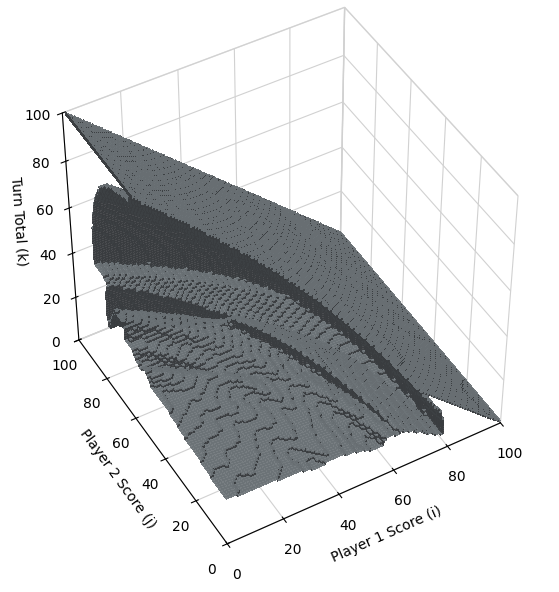

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ah.plot_figure3_policy_boundary(
    fig3_data,
    ax=ax,
    boundary_alpha=0.92,
)


ax.view_init(elev=45, azim=240)
plt.savefig(figures_dir / "Figure3a.png", bbox_inches='tight', dpi=300)
plt.show()


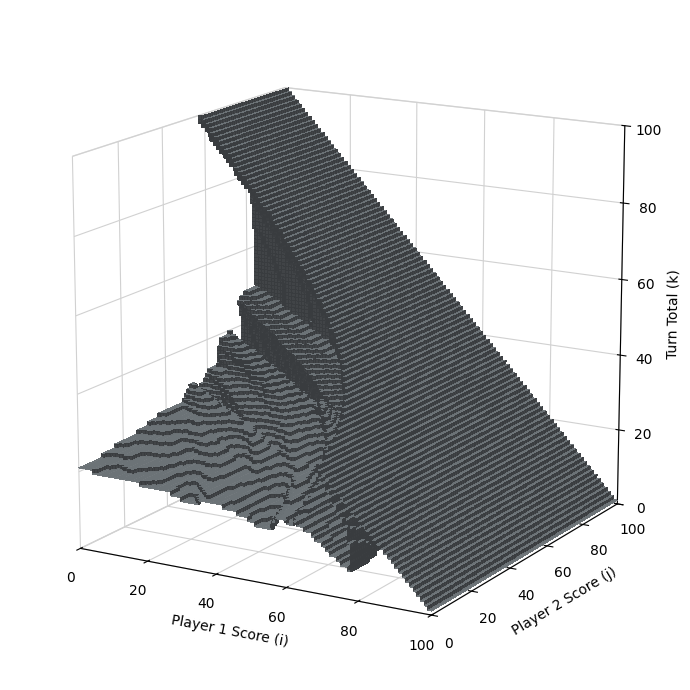

In [5]:
# ax = ah.plot_figure3_policy_boundary(full_fig3_data, title=None)
# ax.view_init(elev=15, azim=-60)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ah.plot_figure3_policy_boundary(
    fig3_data,
    ax=ax,
    boundary_alpha=0.96,
    max_surface_jump=100,
)

ax.view_init(elev=15, azim=-60)
plt.savefig(figures_dir / "Figure3b.png", bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()




# 3. Figure 4

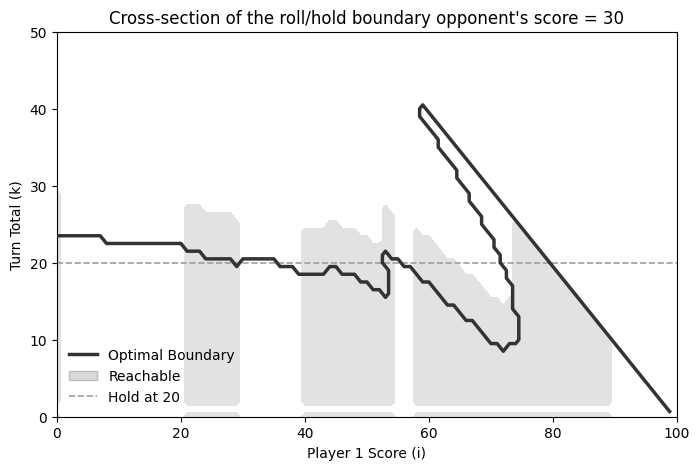

In [6]:
ah.plot_figure4_cross_section(
    full_fig4_data,
    hold_at_threshold=20,
    title="Cross-section of the roll/hold boundary opponent's score = 30"
)
plt.ylim(0, 50)
plt.xlim(0, 100)
plt.savefig(figures_dir / "Figure4.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. Figure 5

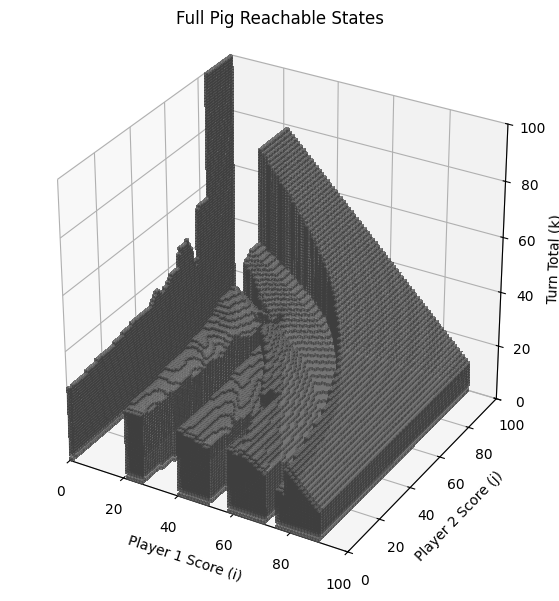

In [7]:
ax = ah.plot_figure5_reachable_states(
    full_fig5_data,
    max_points=60000,
    surface=True,
    title="Full Pig Reachable States"
)
plt.savefig(figures_dir / "Figure5.png", bbox_inches='tight', dpi=300)
plt.show()

# 4. Figure 6

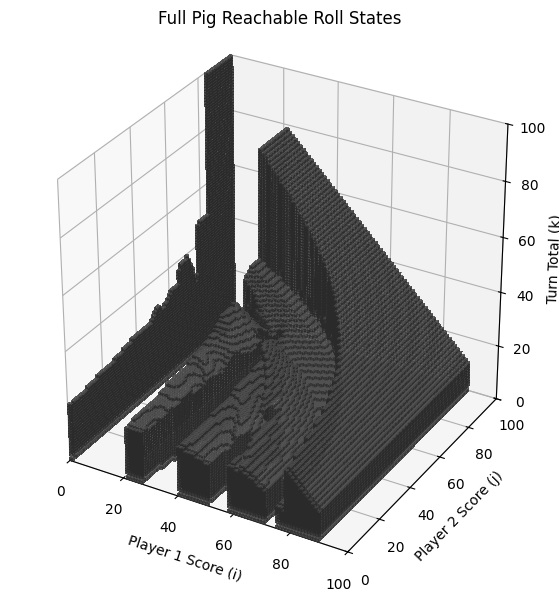

In [8]:
ax = ah.plot_figure6_reachable_continue_states(
    full_fig6_data,
    max_points=60000,
    surface=True,
    title="Full Pig Reachable Roll States"
)
plt.savefig(figures_dir / "Figure6.png", bbox_inches='tight', dpi=300)
plt.show()

# 5. Figure 7

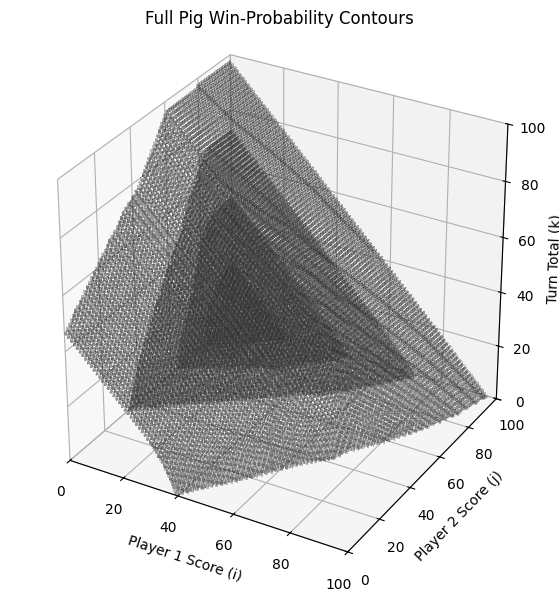

In [9]:
if full_fig7_data is None:
    print("Figure 7 skipped because full_V is not available.")
else:
    ax = ah.plot_figure7_probability_contours(
        full_fig7_data,
        title="Full Pig Win-Probability Contours",
        max_faces_per_level=20000,
    )
    plt.savefig(figures_dir / "Figure7.png", bbox_inches='tight', dpi=300)
    plt.show()